In [19]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [9]:
import pandas as pd
from zipfile import ZipFile
from io import BytesIO
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

# Descargar el ZIP
content = requests.get(url).content

# Abrir el ZIP
with ZipFile(BytesIO(content)) as z:
    with z.open("SMSSpamCollection") as f:
        df = pd.read_csv(
            f,
            sep="\t",
            names=["class", "text"]
        )

df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df["class"].value_counts()

class
ham     4825
spam     747
Name: count, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["class"],
    test_size=0.25,
    random_state=42,
    stratify=df["class"]
)

In [12]:
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(vectorizer.get_feature_names_out()[:50])

['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '02' '0207' '02072069400' '02073162414' '02085076972' '021'
 '03' '04' '0430' '05' '050703' '0578' '06' '07' '07008009200'
 '07046744435' '07099833605' '07123456789' '0721072' '07732584351'
 '07734396839' '07742676969' '07753741225' '07781482378' '07786200117'
 '077xxx' '078' '07801543489' '07808' '07808247860' '07808726822'
 '07815296484' '07821230901' '078498' '0789xxxxxxx' '0796xxxxxx'
 '07xxxxxxxxx' '0800' '08000407165' '08000839402' '08000930705'
 '08000938767']


In [13]:
modelo = MultinomialNB()

modelo.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3619., 560.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7387)","[[ 0., 0., 1.,..., 1., 0., 1.], [ 9.,20., 0.,..., 0., 1., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7387)","[[-10.9 ,-10.9 ,-10.21,...,-10.21,-10.9 ,-10.21], [ -7.63, -6.89, -9.93,..., -9.93, -9.24, -9.93]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7387


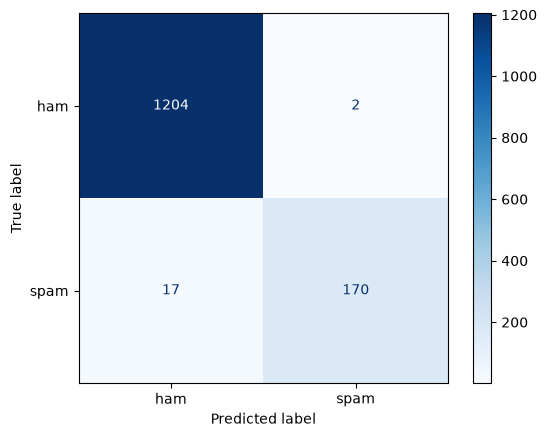

In [35]:
y_pred = modelo.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot(cmap="Blues")

plt.show()



In [37]:
print('Métricas estadísticas para comparar modelos de clasificación binaria (spam vs ham)')
acc = accuracy_score(y_test, y_pred)
# Accuracy = (TP + TN) / (TP + TN + FP + FN)
# Accuracy o exactitud, mide el porcentaje de predicciones correctas sobre el total de predicciones realizadas. 
# Es una métrica útil cuando las clases están balanceadas, pero puede ser engañosa en conjuntos de datos desbalanceados.
print(f"Exactitud = {acc:.4f}. Porcentaje de predicciones correctas sobre el total de predicciones realizadas")

# Recall — Sensibilidad / Exhaustividad
# De todos los positivos reales, ¿cuántos encontré?
print(f"Sensibilidad = {recall_score(y_test, y_pred, pos_label='spam'):.4f}. De todos los positivos reales, ¿cuántos encontré?")

#Precision — Precisión
# De todos los que predije positivos, ¿cuántos realmente lo eran?
print(f"Precisión = {precision_score(y_test, y_pred, pos_label='spam'):.4f}. De todos los que predije positivos, ¿cuántos realmente lo eran?")

# F1-score
# Combina las dos anteriores mediante la media armónica:
print(f"F1-score = {f1_score(y_test, y_pred, pos_label='spam'):.4f}. Combina la sensibilidad y la precisión mediante la media armónica")

# Specificity — Especificidad
# De todos los negativos que realmente existían, ¿cuántos reconocí correctamente como negativos?
# Equivale al recall de la clase negativa
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
print(f"Especificidad = {specificity:.4f}. De todos los negativos que realmente existían, ¿cuántos reconocí correctamente como negativos?")



Métricas estadísticas para comparar modelos de clasificación binaria (spam vs ham)
Exactitud = 0.9864. Porcentaje de predicciones correctas sobre el total de predicciones realizadas
Sensibilidad = 0.9091. De todos los positivos reales, ¿cuántos encontré?
Precisión = 0.9884. De todos los que predije positivos, ¿cuántos realmente lo eran?
F1-score = 0.9471. Combina la sensibilidad y la precisión mediante la media armónica
Especificidad = 0.9983. De todos los negativos que realmente existían, ¿cuántos reconocí correctamente como negativos?


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
# Probabilidad de pertenecer a la clase positiva: spam
spam_idx = list(modelo.classes_).index("spam")
y_score = modelo.predict_proba(X_test_vec)[:, spam_idx]
print('Algunos valores de probabilidad: ')
print(y_score[:10])

# Convertimos la clase real a 0/1
y_test_bin = (y_test == "spam").astype(int)

# Curva ROC
# La curva ROC (Receiver Operating Characteristic) es una representación gráfica que ilustra el rendimiento de un clasificador binario a medida que se varía el umbral de decisión. 
# La curva ROC se traza con la tasa de verdaderos positivos (TPR) en el eje Y frente a la tasa de falsos positivos (FPR) en el eje X.
# Permite ver el comportamiento ante diferentes umbrales de decisión y es útil para comparar diferentes modelos de clasificación.
fpr, tpr, thresholds = roc_curve(y_test_bin, y_score)

# Área bajo la curva
auc = roc_auc_score(y_test_bin, y_score)

print(f"Área bajo la curva ROC = {auc:.4f}. Mide la capacidad del modelo para distinguir entre clases. Un valor de 0.5 indica un modelo sin capacidad discriminativa, mientras que un valor de 1.0 indica un modelo perfecto."  )

Algunos valores de probabilidad: 
[2.08132765e-05 4.00173808e-01 3.55666809e-06 5.69639744e-04
 3.13054948e-06 1.40988553e-01 3.10392608e-06 1.14734379e-68
 9.99999997e-01 2.60003550e-14]
Área bajo la curva ROC = 0.9824. Mide la capacidad del modelo para distinguir entre clases. Un valor de 0.5 indica un modelo sin capacidad discriminativa, mientras que un valor de 1.0 indica un modelo perfecto.


In [23]:
J = tpr - fpr
idx_opt = np.argmax(J)

fpr_opt = fpr[idx_opt]
tpr_opt = tpr[idx_opt]
threshold_opt = thresholds[idx_opt]

print(f"Umbral óptimo = {threshold_opt:.4f}")
print(f"TPR / Sensibilidad = {tpr_opt:.4f}")
print(f"FPR = {fpr_opt:.4f}")
print(f"Especificidad = {1 - fpr_opt:.4f}")

Umbral óptimo = 0.1048
TPR / Sensibilidad = 0.9519
FPR = 0.0191
Especificidad = 0.9809


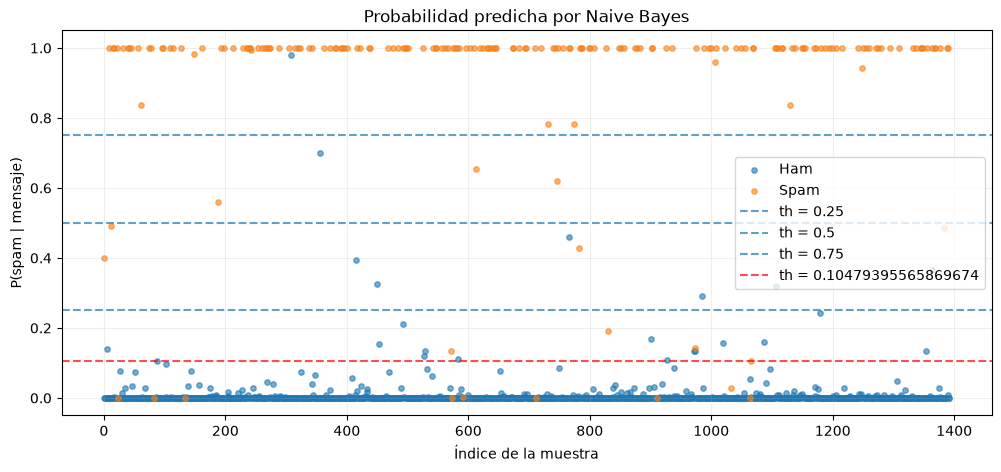

In [31]:
plt.figure(figsize=(12, 5))

idx = np.arange(len(y_score))

# Clase real: Ham
mask_ham = y_test_bin == 0
plt.scatter(
    idx[mask_ham],
    y_score[mask_ham],
    s=15,
    alpha=0.6,
    label="Ham"
)

# Clase real: Spam
mask_spam = y_test_bin == 1
plt.scatter(
    idx[mask_spam],
    y_score[mask_spam],
    s=15,
    alpha=0.6,
    label="Spam"
)

# Umbrales
for th in [0.25, 0.50, 0.75]:
    plt.axhline(
        th,
        linestyle="--",
        alpha=0.7,
        label=f"th = {th}"
    )

plt.axhline(
        threshold_opt,
        linestyle="--",
        alpha=0.7,
        color="red",
        label=f"th = {threshold_opt}"
    )

plt.xlabel("Índice de la muestra")
plt.ylabel("P(spam | mensaje)")
plt.title("Probabilidad predicha por Naive Bayes")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)

plt.show()

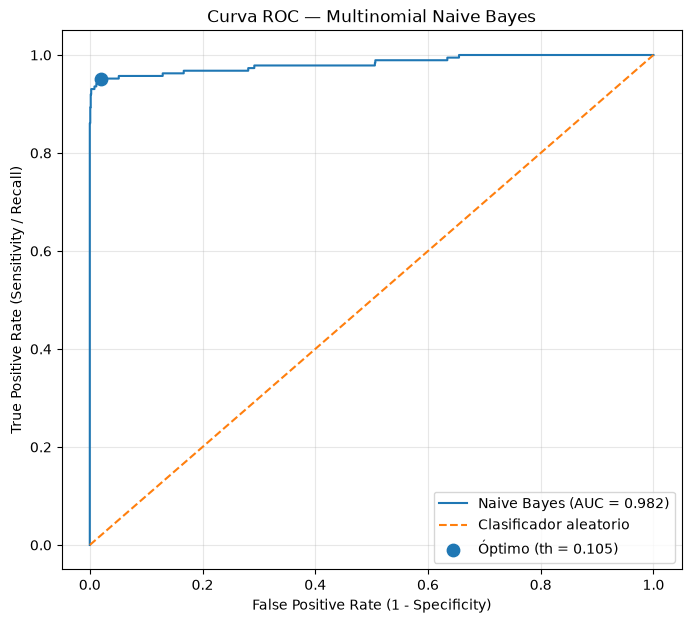

In [27]:
plt.figure(figsize=(8, 7))

# Curva ROC
plt.plot(
    fpr,
    tpr,
    label=f"Naive Bayes (AUC = {auc:.3f})"
)

# Clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Clasificador aleatorio"
)

# Punto óptimo
plt.scatter(
    fpr_opt,
    tpr_opt,
    s=80,
    zorder=3,
    label=f"Óptimo (th = {threshold_opt:.3f})"
)



plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("Curva ROC — Multinomial Naive Bayes")
plt.legend()
plt.grid(alpha=0.3)

plt.show()